# Conservatively diagnosing model transports into an arbitrary closed region with `sectionate`

## Import packages

In [1]:
import numpy as np
import xgcm
import xarray as xr
import matplotlib.pyplot as plt

import sectionate
print(f"Sectionate version: {sectionate.__version__}")

Sectionate version: 0.3.3


## Load example model grid and transport diagnosics

In [2]:
from load_example_model_grid import load_MOM6_example_grid
grid = load_MOM6_example_grid()
ds = grid._ds

## Define the two OSNAP sections:

In [3]:
Labrador_section_lons=[-56.8775, -52.0956, -49.8604, -47.6107, -44.8000, -50, -65, -65]
Labrador_section_lats=[52.0166, 52.6648, 53.5577, 58.8944, 60.4000, 71, 63.5, 57.5]
Labrador_section_lons = np.append(Labrador_section_lons, Labrador_section_lons[0])
Labrador_section_lats = np.append(Labrador_section_lats, Labrador_section_lats[0])

## Closed section surrounding Labrador Sea

In [4]:
i_c, j_c, lons_c, lats_c = sectionate.grid_section(
    grid,
    Labrador_section_lons,
    Labrador_section_lats,
)

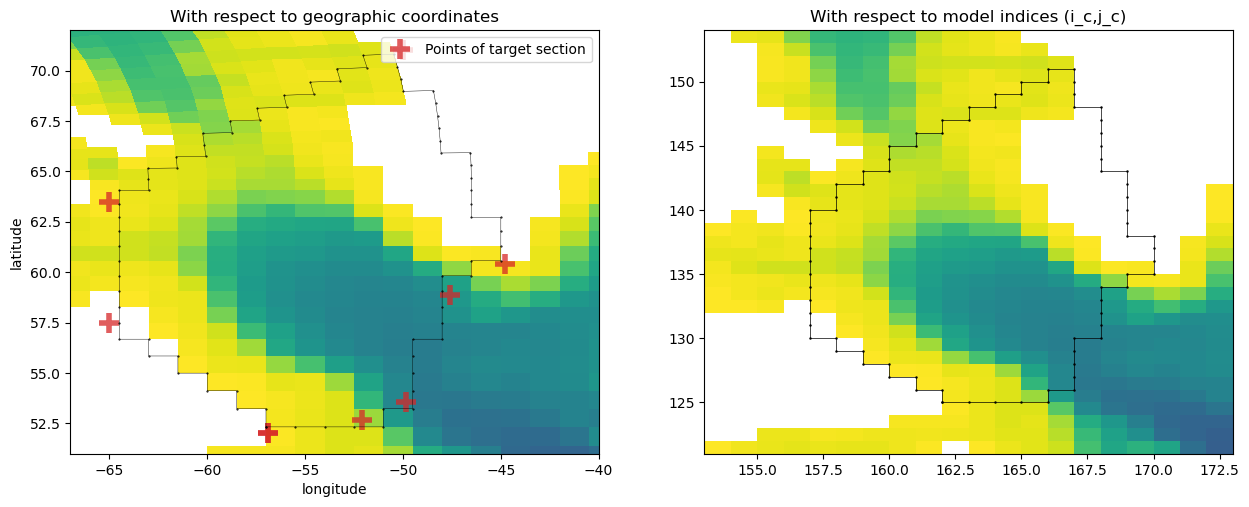

In [5]:
depth_masked = ds['deptho'].where(ds['deptho'] != 0)

plt.figure(figsize=[15,5.5])
plt.subplot(1,2,1)
plt.pcolormesh(ds['geolon_c'], ds['geolat_c'], depth_masked, cmap="viridis_r")
plt.plot(Labrador_section_lons, Labrador_section_lats, "C3+", markersize=15., mew=4., alpha=0.75, label="Points of target section")
plt.plot(lons_c, lats_c, 'k.-', markersize=1., lw=0.3)
plt.axis([-67,-40, 51, 72])
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.title("With respect to geographic coordinates")
plt.legend(loc="upper right")

plt.subplot(1,2,2)
plt.pcolormesh(depth_masked, cmap="viridis_r")
plt.plot(i_c, j_c, 'k.-', markersize=1.5, lw=0.5)
plt.axis(np.array([920, 1040, 730, 925])//6)
plt.title("With respect to model indices (i_c,j_c)")
plt.show()

### Plot the hydrography and cell-integrated mass transport across the section

In [6]:
T = sectionate.extract_tracer('thetao', grid, i_c, j_c)

In [7]:
Trp = sectionate.convergent_transport(grid, i_c, j_c, layer="sigma2_l", interface="sigma2_i")
Trp = Trp.assign_coords({"distance": xr.DataArray(Trp.dl.cumsum("sect").values, dims=("sect",), attrs={"units":"m"})})

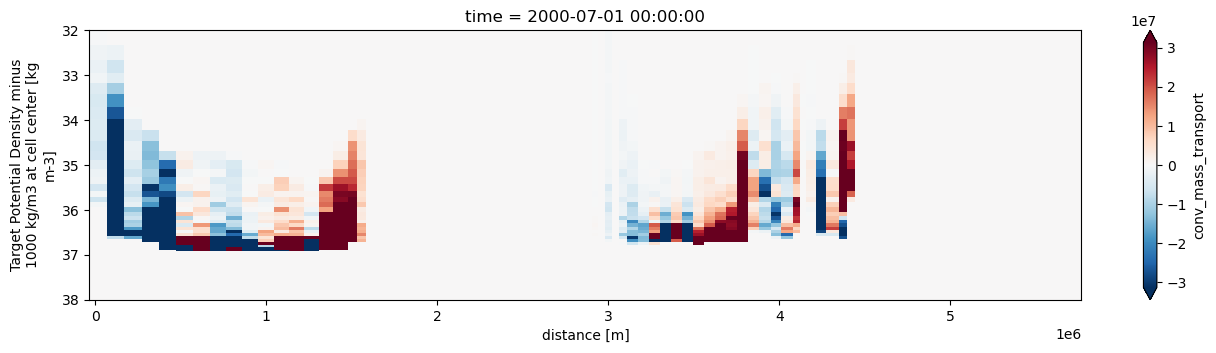

In [8]:
plt.figure(figsize=(16, 3.5))
Trp.isel(time=0)['conv_mass_transport'].swap_dims({'sect':'distance'}).plot(
    cmap='RdBu_r', x="distance", yincrease=False, ylim=[38,32], robust=True
);

### Visualizing the normal vectors to understand the orientation of the cross-section transports

Unlike the open transects in the OSNAP example, this section is **closed** — it encloses the Labrador Sea. For a closed section, `convergent_transport` uses its default `positive_in=True` convention: positive transport is directed **inward**, into the enclosed region. Sectionate infers the inward direction from the polygon's orientation, so no manual sign flip is needed and the result is independent of the order in which the waypoints are traced. The normal vectors below all point into the Labrador Sea, confirming the convergent (inward-positive) orientation.

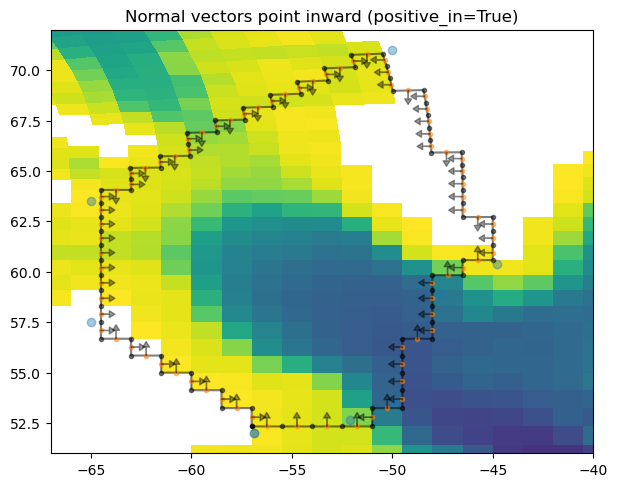

In [9]:
plt.figure(figsize=(7, 5.5))
plt.pcolormesh(ds['geolon_c'], ds['geolat_c'], depth_masked, vmin=0, vmax=5000, cmap="viridis_r")

plt.plot(Labrador_section_lons, Labrador_section_lats, "C0o", alpha=0.4)
scale = 0.7
for (var, lon, lat, sign) in zip(
    Trp.dir.values,
    Trp.lon.values,
    Trp.lat.values,
    Trp.sign.values
    ):
    if var=="V":
        efact = 0.
        nfact = sign
    if var=="U":
        efact = sign
        nfact = 0.

    plt.annotate(
        '', xy=(lon+scale*float(efact), lat+scale*float(nfact)),  xycoords='data',
        xytext=(lon, lat),
        arrowprops=dict(facecolor='black', shrink=0.01, width=0.25, headwidth=5., headlength=4., alpha=0.4),
        horizontalalignment='center', verticalalignment='center'
    )
plt.plot(lons_c, lats_c, "ko-", alpha=0.5, markersize=3, label="tracer cell corners (vorticity grid)")
plt.plot(Trp.lon, Trp.lat, "C1o", alpha=0.5, lw=1, markersize=3, label="velocity cells (faces normal to section)")
plt.title("Normal vectors point inward (positive_in=True)")
plt.axis([-67, -40, 51, 72]);